First 5 rows:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


None


Missing values:


Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


After cleaning:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


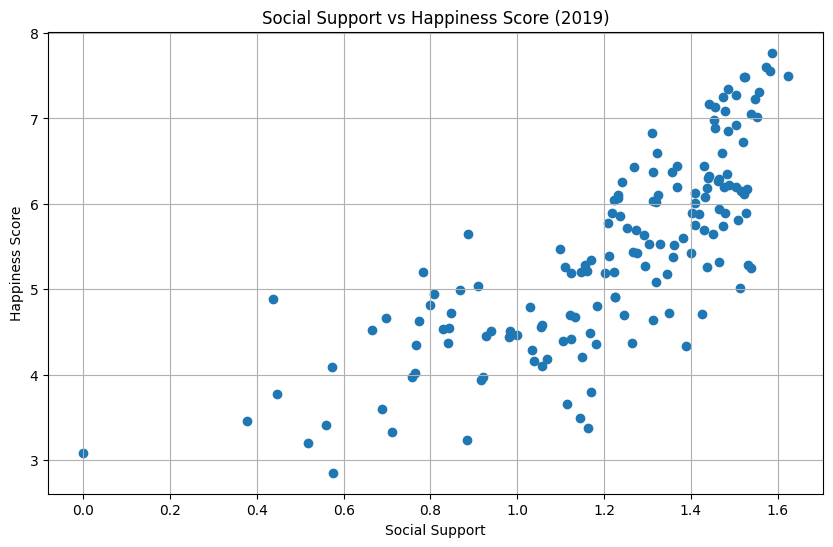

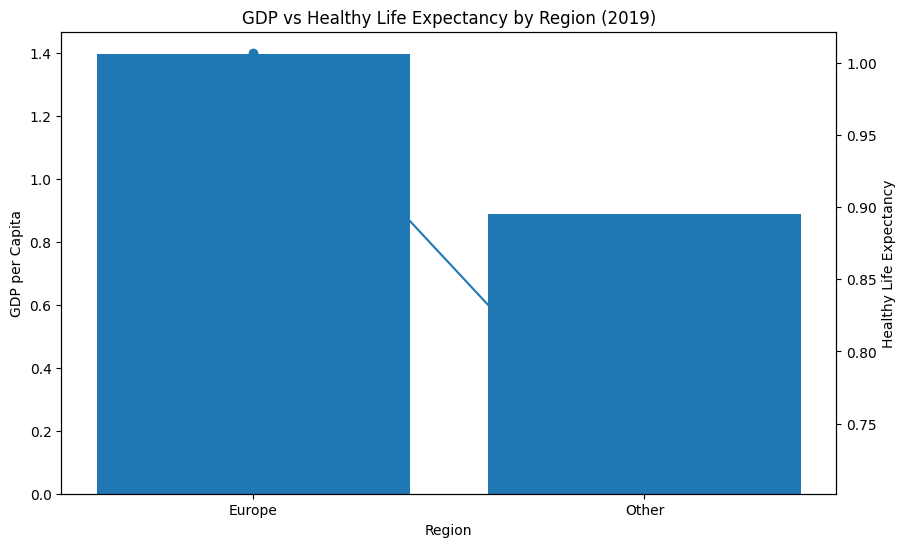

In [10]:

import pandas as pd
import matplotlib.pyplot as plt

# For bigger charts
plt.rcParams['figure.figsize'] = (10,6)


df = pd.read_csv("2019.csv")

print("First 5 rows:")
display(df.head())

print("\nInfo:")
display(df.info())

print("\nMissing values:")
display(df.isna().sum())

df = df.dropna(axis=1, how='all')

df = df.fillna(df.mean(numeric_only=True))

print("\nAfter cleaning:")
display(df.head())


plt.figure()
plt.scatter(df["Social support"], df["Score"])
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")
plt.title("Social Support vs Happiness Score (2019)")
plt.grid(True)
plt.show()


regions = {
    "Finland": "Europe", "Denmark": "Europe", "Norway": "Europe",
    "Iceland": "Europe", "Netherlands": "Europe",
}


df["Region"] = df["Country or region"].map(regions).fillna("Other")


region_group = df.groupby("Region").mean(numeric_only=True)


fig, ax1 = plt.subplots()


ax1.bar(region_group.index, region_group["GDP per capita"])
ax1.set_xlabel("Region")
ax1.set_ylabel("GDP per Capita")
ax1.set_title("GDP vs Healthy Life Expectancy by Region (2019)")

ax2 = ax1.twinx()
ax2.plot(region_group.index, region_group["Healthy life expectancy"], marker="o")
ax2.set_ylabel("Healthy Life Expectancy")

plt.xticks(rotation=45)
plt.show()
